# **A Comparative Analysis of Preprocessing Pipelines and Regularization Techniques for Epileptic Seizure Prediction Using Logistic Regression**

***Step # 0: Checking for Libraries***

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

print("All libraries loaded successfully")

All libraries loaded successfully


# **Step 01: Seizure Dataset Collection and Uploading**

## **Description**

In this phase, multiple seizure-related datasets are collected and analyzed based on their size, class imbalance, and feature characteristics. The purpose is to evaluate how different data properties influence model learning and generalization performance.

In [161]:
# Dataset paths

dataset1 = r"D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\Epileptic Seizure Recognition.csv"

dataset2 = r"D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\epilepsy_federated_dataset.csv"

dataset3 = r"D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_events.csv"


# Load datasets

df1 = pd.read_csv(dataset1)
df2 = pd.read_csv(dataset2)
df3 = pd.read_csv(dataset3)

print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)
print("Dataset 3 Shape:", df3.shape)

Dataset 1 Shape: (11500, 180)
Dataset 2 Shape: (289010, 52)
Dataset 3 Shape: (198, 3)


# **Inspect Dataset Structure**
## Description

This step is performed to understand the structure and characteristics of each dataset. Inspecting the first few rows helps identify feature types, target labels, missing values, and overall dataset organization before preprocessing begins.

In [162]:
print("========== DATASET 1 ==========")
display(df1.head())

print("========== DATASET 2 ==========")
display(df2.head())

print("========== DATASET 3 ==========")
display(df3.head())

========== DATASET 1 ==========


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


========== DATASET 2 ==========


,Mean_EEG_Amplitude,EEG_Std_Dev,EEG_Skewness,EEG_Kurtosis,Zero_Crossing_Rate,Root_Mean_Square,Peak_to_Peak_Amplitude,Signal_Energy,Variance_of_EEG_Signals,Interquartile_Range,...,Post_Seizure_Recovery,Seizure_Frequency_Per_Hour,Interictal_Spike_Rate,Seizure_Intensity_Index,Age,Gender,Medication_Status,Seizure_History,Multi_Class_Label,Seizure_Type_Label
0,0.463995,1.560095,-1.953752,1.417816,53.428102,2.552078,3.734923,17.276018,4.627323,2.054438,...,0.382942,3.250527,6.405068,0.686015,87,0,1,18,0,2
1,0.324632,0.953233,-0.034527,1.333842,61.486037,1.968715,1.285857,8.099144,3.572132,0.541116,...,0.423757,9.210367,3.192447,0.944232,1,1,0,0,2,0
2,0.499497,0.419182,-0.697510,7.345670,33.569696,2.226112,1.869052,7.211445,4.022814,0.939826,...,0.407296,3.212498,4.143878,0.288099,53,1,1,7,0,1
3,0.721730,0.962900,-1.161993,0.774990,81.811036,2.349506,3.524583,13.940857,2.152732,1.032526,...,0.184500,1.310543,7.854328,1.463863,18,0,0,18,0,2
4,0.305064,1.253647,-1.166630,1.265767,38.618300,1.994878,2.902625,7.698449,4.332478,0.660386,...,0.368572,6.087262,1.659506,0.121632,12,1,1,3,1,1


========== DATASET 3 ==========


,series_id,onset,offset
0,chb01_03.edf,2996,3036
1,chb01_04.edf,1467,1494
2,chb01_15.edf,1732,1772
3,chb01_16.edf,1015,1066
4,chb01_18.edf,1720,1810


# **Verify Dataset Dimensions**
## Description

The dimensions of each dataset are analyzed to understand the number of samples and features available. This information is important for evaluating dataset complexity, computational requirements, and potential overfitting risks.

In [163]:
print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)
print("Dataset 3 Shape:", df3.shape)

Dataset 1 Shape: (11500, 180)
Dataset 2 Shape: (289010, 52)
Dataset 3 Shape: (198, 3)


# **Step 02: Exploratory Data Analysis (EDA)**

## **Description**

Exploratory Data Analysis (EDA) is performed to understand the statistical and structural properties of the datasets before preprocessing and modeling. This step helps identify missing values, feature distributions, dataset imbalance, and potential preprocessing requirements.

EDA is extremely important because preprocessing decisions and model performance strongly depend on dataset characteristics.

# **Step 2.1: Check Dataset Information**
# Description

This step displays dataset structure, feature types, and non-null values. It helps identify numerical/categorical features and possible missing data issues

In [164]:
print("========== DATASET 1 INFO ==========")
df1.info()

print("\n========== DATASET 2 INFO ==========")
df2.info()

print("\n========== DATASET 3 INFO ==========")
df3.info()

========== DATASET 1 INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), str(1)
memory usage: 15.8 MB

========== DATASET 2 INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 289010 entries, 0 to 289009
Data columns (total 52 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Mean_EEG_Amplitude                  289010 non-null  float64
 1   EEG_Std_Dev                         289010 non-null  float64
 2   EEG_Skewness                        289010 non-null  float64
 3   EEG_Kurtosis                        289010 non-null  float64
 4   Zero_Crossing_Rate                  289010 non-null  float64
 5   Root_Mean_Square                    289010 non-null  float64
 6   Peak_to_Peak_Amplitude              289010 non-null  float64
 7   Signal_Energy                       289010 non-null  float64
 8   Variance_of

# **Step 2.2 Check Missing Values**
# Description

Missing value analysis is necessary because incomplete data can negatively affect preprocessing pipelines and model learning. This step identifies whether imputation or cleaning is required.

In [165]:
print("========== MISSING VALUES ==========")

print("\nDataset 1 Missing Values:")
print(df1.isnull().sum())

print("\nDataset 2 Missing Values:")
print(df2.isnull().sum())

print("\nDataset 3 Missing Values:")
print(df3.isnull().sum())

========== MISSING VALUES ==========

Dataset 1 Missing Values:
Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

Dataset 2 Missing Values:
Mean_EEG_Amplitude                    0
EEG_Std_Dev                           0
EEG_Skewness                          0
EEG_Kurtosis                          0
Zero_Crossing_Rate                    0
Root_Mean_Square                      0
Peak_to_Peak_Amplitude                0
Signal_Energy                         0
Variance_of_EEG_Signals               0
Interquartile_Range                   0
Auto_Correlation_of_EEG_Signals       0
Cross_Correlation_Between_Channels    0
Hjorth_Mobility                       0
Hjorth_Complexity                     0
Line_Length_Feature                   0
Delta_Band_Power                      0
Theta_Band_Power                      0
Alpha_Band_Power                      0
Beta_Band_Power     

# **Step 2.3 — Generate Statistical Summary**
# Description

Statistical summaries provide insight into feature distributions including mean, standard deviation, minimum, and maximum values. This helps determine whether normalization or scaling is necessary

In [166]:
print("========== DATASET 1 SUMMARY ==========")
display(df1.describe())

print("========== DATASET 2 SUMMARY ==========")
display(df2.describe())

print("========== DATASET 3 SUMMARY ==========")
display(df3.describe())

========== DATASET 1 SUMMARY ==========


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


========== DATASET 2 SUMMARY ==========


,Mean_EEG_Amplitude,EEG_Std_Dev,EEG_Skewness,EEG_Kurtosis,Zero_Crossing_Rate,Root_Mean_Square,Peak_to_Peak_Amplitude,Signal_Energy,Variance_of_EEG_Signals,Interquartile_Range,...,Post_Seizure_Recovery,Seizure_Frequency_Per_Hour,Interictal_Spike_Rate,Seizure_Intensity_Index,Age,Gender,Medication_Status,Seizure_History,Multi_Class_Label,Seizure_Type_Label
count,2.890100e+05,2.890100e+05,2.890100e+05,2.890100e+05,289010.000000,289010.000000,2.890100e+05,289010.000000,2.890100e+05,2.890100e+05,...,2.890100e+05,2.890100e+05,289010.000000,2.890100e+05,289010.000000,289010.000000,289010.000000,289010.00000,289010.000000,289010.000000
mean,3.759015e-01,1.402758e+00,-6.149603e-01,6.205832e+00,60.521465,1.864850,3.008423e+00,11.898784,4.201707e+00,1.100759e+00,...,3.761180e-01,5.737106e+00,4.207933,1.404153e+00,45.007706,0.550548,0.399363,9.48207,0.851002,0.551801
std,2.091862e-01,8.103421e-01,6.616630e-01,4.979964e+00,28.807006,0.550108,1.675024e+00,6.625076,2.341222e+00,7.298437e-01,...,2.092639e-01,3.806587e+00,2.344759,8.084777e-01,25.670457,0.497439,0.489768,5.77315,1.062167,0.740509
min,2.741494e-07,1.520767e-08,-7.241982e+00,2.455244e-08,0.000020,0.069773,2.459678e-08,0.000003,8.826758e-08,4.701857e-09,...,2.671845e-08,2.997953e-07,0.000007,3.184166e-08,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,2.207229e-01,7.971894e-01,-8.820291e-01,2.218810e+00,39.645731,1.477960,1.766865e+00,6.993723,2.462593e+00,5.406502e-01,...,2.205437e-01,2.814971e+00,2.470119,8.007821e-01,23.000000,0.000000,0.000000,4.00000,0.000000,0.000000
50%,3.536820e-01,1.312422e+00,-3.966837e-01,5.206509e+00,58.001585,1.837174,2.831074e+00,11.195682,3.957402e+00,9.994167e-01,...,3.542973e-01,5.213557e+00,3.960291,1.315268e+00,45.000000,1.000000,0.000000,9.00000,0.000000,0.000000
75%,5.060304e-01,1.905273e+00,-1.293361e-01,9.060643e+00,78.715237,2.218587,4.051138e+00,16.018657,5.655822e+00,1.545027e+00,...,5.056495e-01,8.052974e+00,5.663812,1.902422e+00,67.000000,1.000000,1.000000,14.00000,2.000000,1.000000
max,1.678600e+00,6.134043e+00,-2.051856e-09,4.278456e+01,223.480085,5.062378,1.287086e+01,53.628832,2.047479e+01,6.593378e+00,...,1.665525e+00,2.886076e+01,19.471340,6.285143e+00,89.000000,1.000000,1.000000,19.00000,3.000000,2.000000


========== DATASET 3 SUMMARY ==========


,onset,offset
count,198.000000,198.000000
mean,2503.722222,2562.363636
std,2416.723773,2416.201234
min,38.000000,60.000000
25%,1082.750000,1114.750000
50%,1948.000000,1988.500000
75%,2994.000000,3072.500000
max,13688.000000,13831.000000


# **Step 2.4 — Identify Target Columns**
# Description

Machine learning models require a clearly defined target variable. This step identifies the seizure classification label column in each dataset.

In [167]:
print("Dataset 1 Columns:")
print(df1.columns)

print("\nDataset 2 Columns:")
print(df2.columns)

print("\nDataset 3 Columns:")
print(df3.columns)

Dataset 1 Columns:
Index(['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='str', length=180)

Dataset 2 Columns:
Index(['Mean_EEG_Amplitude', 'EEG_Std_Dev', 'EEG_Skewness', 'EEG_Kurtosis',
       'Zero_Crossing_Rate', 'Root_Mean_Square', 'Peak_to_Peak_Amplitude',
       'Signal_Energy', 'Variance_of_EEG_Signals', 'Interquartile_Range',
       'Auto_Correlation_of_EEG_Signals', 'Cross_Correlation_Between_Channels',
       'Hjorth_Mobility', 'Hjorth_Complexity', 'Line_Length_Feature',
       'Delta_Band_Power', 'Theta_Band_Power', 'Alpha_Band_Power',
       'Beta_Band_Power', 'Gamma_Band_Power',
       'Low_to_High_Frequency_Power_Ratio', 'Power_Spectral_Density',
       'Spectral_Edge_Frequency', 'Spectral_Entropy',
       'Fourier_Transform_Features', 'Wavelet_Entropy', 'Wavelet_Energy',
       'Discrete_Wavelet_Transform', 'Continuous_Wavelet_Transform',


# **Step 03: Data Cleaning and Preprocessing Pipeline A**
# Pipeline A
# Normalization → Noise Removal → Feature Selection

# Description

In this preprocessing pipeline, the datasets are cleaned and transformed before model training. The objective is to improve data quality, reduce noise, and retain only the most informative features for seizure prediction.

This pipeline follows the sequence:

Data Cleaning →
Target Label Preparation →
Normalization →
Noise Removal →
Feature Selection

The purpose is to investigate how preprocessing order influences classification performance and generalization ability.

# Step 3.1:Prepare Dataset 1
Description

In this step, Dataset 1 is cleaned and separated into features and target labels. The seizure class labels are converted into binary form for Logistic Regression.

In [168]:
# Copy dataset

data1 = df1.copy()

# Remove unnecessary column if present
if 'Unnamed' in data1.columns[0]:
    data1 = data1.iloc[:, 1:]

# Check target column
print(data1.columns[-1])

# Convert target into binary classification
# Seizure class = 1
# Non-seizure classes = 0

data1['y'] = data1['y'].apply(lambda x: 1 if x == 1 else 0)

# Separate features and target

X1 = data1.drop('y', axis=1)
y1 = data1['y']

print("Feature Shape:", X1.shape)
print("Target Shape:", y1.shape)

print("\nClass Distribution:")
print(y1.value_counts())

y
Feature Shape: (11500, 178)
Target Shape: (11500,)

Class Distribution:
y
0    9200
1    2300
Name: count, dtype: int64


# **Step 3.2: Train-Test Split**
# Description

The dataset is divided into training and testing sets to evaluate model generalization on unseen data.

In [169]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

print("Training Shape:", X1_train.shape)
print("Testing Shape:", X1_test.shape)

Training Shape: (9200, 178)
Testing Shape: (2300, 178)


# **Step 3.3 — Normalization Using StandardScaler**
# Description

Normalization standardizes feature values to improve convergence and stability of Logistic Regression.

The StandardScaler transforms data using:

In [170]:
# Standardization

scaler = StandardScaler()

X1_train_scaled = scaler.fit_transform(X1_train)
X1_test_scaled = scaler.transform(X1_test)

print("Normalization completed")

Normalization completed


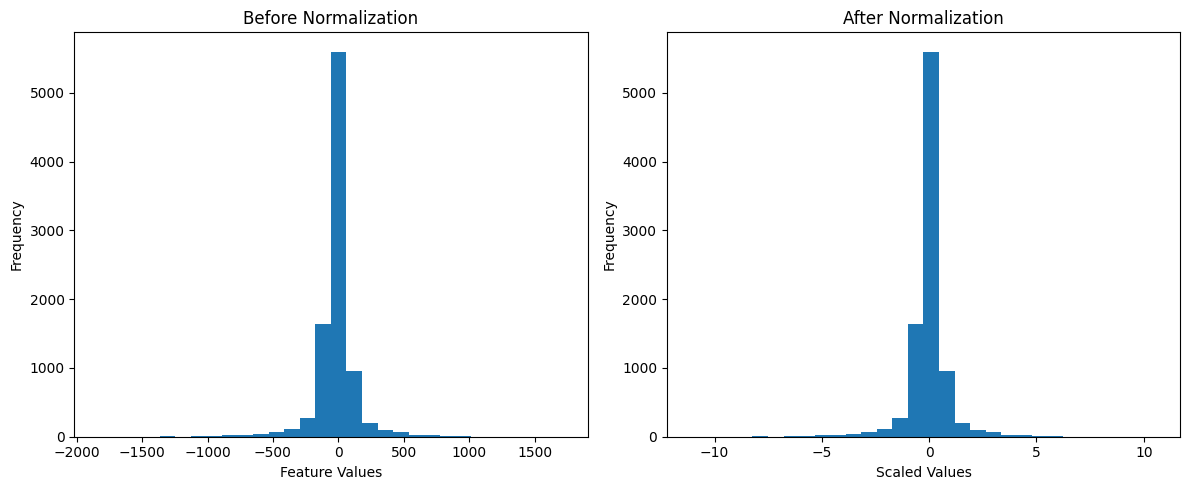

In [171]:
# Select first feature before normalization
feature_before = X1_train.iloc[:, 0]

# Select first feature after normalization
feature_after = X1_train_scaled[:, 0]

plt.figure(figsize=(12,5))

# Before normalization
plt.subplot(1,2,1)
plt.hist(feature_before, bins=30)
plt.title("Before Normalization")
plt.xlabel("Feature Values")
plt.ylabel("Frequency")

# After normalization
plt.subplot(1,2,2)
plt.hist(feature_after, bins=30)
plt.title("After Normalization")
plt.xlabel("Scaled Values")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

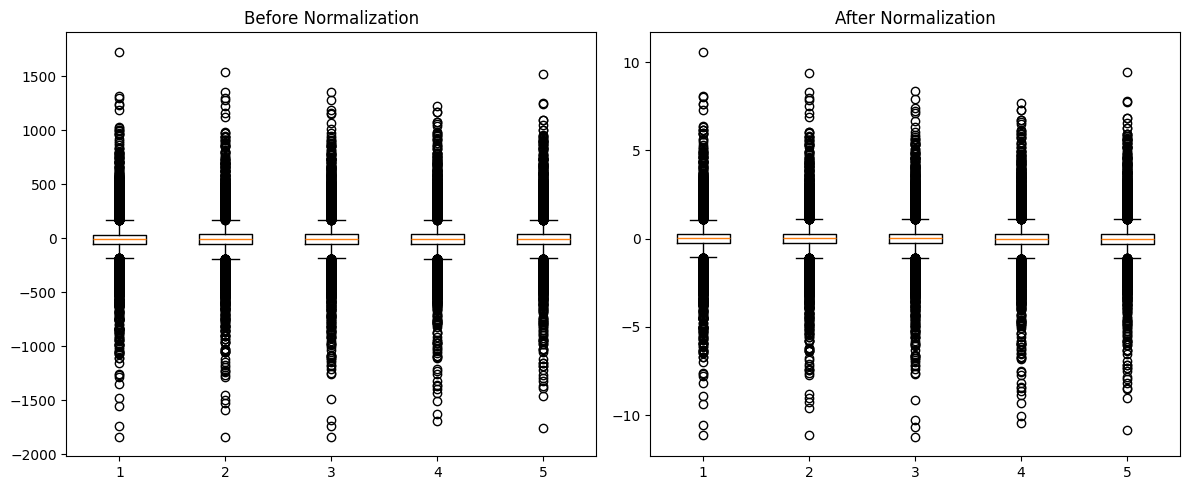

In [172]:
plt.figure(figsize=(12,5))

# Before normalization
plt.subplot(1,2,1)
plt.boxplot(X1_train.iloc[:, :5])
plt.title("Before Normalization")

# After normalization
plt.subplot(1,2,2)
plt.boxplot(X1_train_scaled[:, :5])
plt.title("After Normalization")

plt.tight_layout()
plt.show()

# **Step 3.4:Noise Removal Using Variance Threshold**
# Description

Noise removal eliminates low-variance features that contribute little useful information to classification.

This helps:

reduce dimensionality
decrease overfitting risk
improve model stability

In [173]:
from sklearn.feature_selection import VarianceThreshold

# Remove low variance features

selector = VarianceThreshold(threshold=0.01)

X1_train_var = selector.fit_transform(X1_train_scaled)
X1_test_var = selector.transform(X1_test_scaled)

print("Original Features:", X1_train_scaled.shape[1])
print("Remaining Features:", X1_train_var.shape[1])

Original Features: 178
Remaining Features: 178


# **Step 3.5:Feature Selection Using SelectKBest**
# Description

Feature selection retains the most informative features related to seizure prediction.

This improves:

model interpretability
computational efficiency
generalization performance

In [174]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select best features

kbest = SelectKBest(score_func=f_classif, k=50)

X1_train_final = kbest.fit_transform(X1_train_var, y1_train)
X1_test_final = kbest.transform(X1_test_var)

print("Final Training Shape:", X1_train_final.shape)
print("Final Testing Shape:", X1_test_final.shape)

Final Training Shape: (9200, 50)
Final Testing Shape: (2300, 50)


# “Pipeline A applies normalization before noise removal and feature selection, enabling stable feature scaling and removal of low-information attributes prior to selecting discriminative seizure-related features.”

# **Step 04: Preprocessing Pipeline B**
# Pipeline B
# Feature Extraction → Scaling → PCA

Pipeline B investigates an alternative preprocessing order in which statistical feature extraction is performed before scaling and dimensionality reduction.

This pipeline is designed to evaluate whether transforming raw EEG-related signals into statistical descriptors before normalization improves seizure prediction performance.

The sequence is:

1) Feature Extraction
2) Scaling
3) Principal Component Analysis (PCA)

This pipeline will later be compared with Pipeline A to analyze the impact of preprocessing order on generalization performance.

# **Step 4.1: Create Statistical Features**
# Description

Instead of using all raw features directly, statistical descriptors are extracted from each sample.

The extracted features include:

Mean
Standard deviation
Maximum value
Minimum value
Median

These features summarize signal characteristics and reduce noise sensitivity.

In [175]:
# Create copy of dataset

data2_pipeline = data1.copy()

# Separate features and target

X2 = data2_pipeline.drop('y', axis=1)
y2 = data2_pipeline['y']

# Statistical feature extraction

X2_features = pd.DataFrame()

X2_features['mean'] = X2.mean(axis=1)
X2_features['std'] = X2.std(axis=1)
X2_features['max'] = X2.max(axis=1)
X2_features['min'] = X2.min(axis=1)
X2_features['median'] = X2.median(axis=1)

print("Extracted Feature Shape:", X2_features.shape)

display(X2_features.head())

Extracted Feature Shape: (11500, 5)


,mean,std,max,min,median
0,-16.910112,95.980947,229,-281,-11.5
1,28.112360,473.166815,513,-1716,220.5
2,-44.044944,44.311025,80,-126,-44.5
3,-68.910112,15.968642,-22,-105,-69.0
4,-6.651685,38.802149,78,-103,-1.0


# **Step 4.2: Train-Test Split**
#Description

The extracted statistical features are divided into training and testing sets for model evaluation.

In [176]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_features,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Training Shape:", X2_train.shape)
print("Testing Shape:", X2_test.shape)

Training Shape: (9200, 5)
Testing Shape: (2300, 5)


# **Step 4.3: Scaling Using StandardScaler**
# Description

Feature scaling ensures that all extracted statistical features contribute equally during optimization.

The scaling transformation is:

In [177]:
# Scaling

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("Scaling completed")

Scaling completed


# **Step 4.4: Apply Principal Component Analysis (PCA)**
# Description

PCA reduces feature dimensionality while preserving the maximum amount of variance.

The objective is:

remove redundancy
reduce overfitting risk
improve computational efficiency

PCA transformation:

Z=XW

In [178]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA(n_components=3)

X2_train_pca = pca.fit_transform(X2_train_scaled)
X2_test_pca = pca.transform(X2_test_scaled)

print("Training Shape After PCA:", X2_train_pca.shape)
print("Testing Shape After PCA:", X2_test_pca.shape)

Training Shape After PCA: (9200, 3)
Testing Shape After PCA: (2300, 3)


# **Step 16.5 — Visualize Explained Variance**
# Description

This visualization shows how much information is preserved by each principal component.

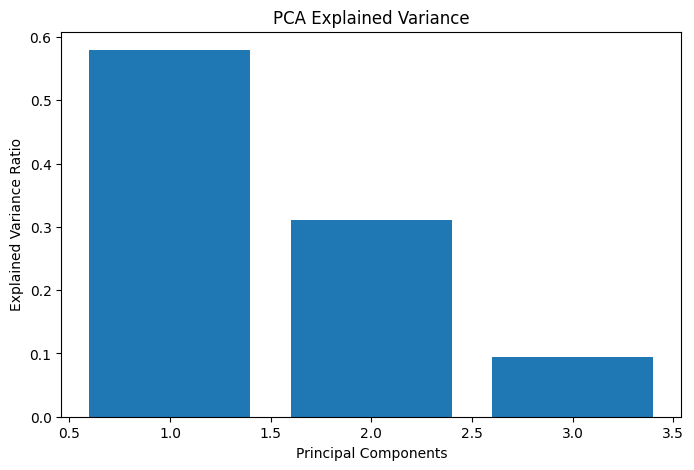

In [179]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(explained_variance)+1),
    explained_variance
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")

plt.show()

# **Step 4.6 — Visualize PCA Projection**
# Description

This visualization projects seizure and non-seizure classes into reduced PCA space.

It helps analyze:

class separability
dimensionality reduction quality
clustering behavior

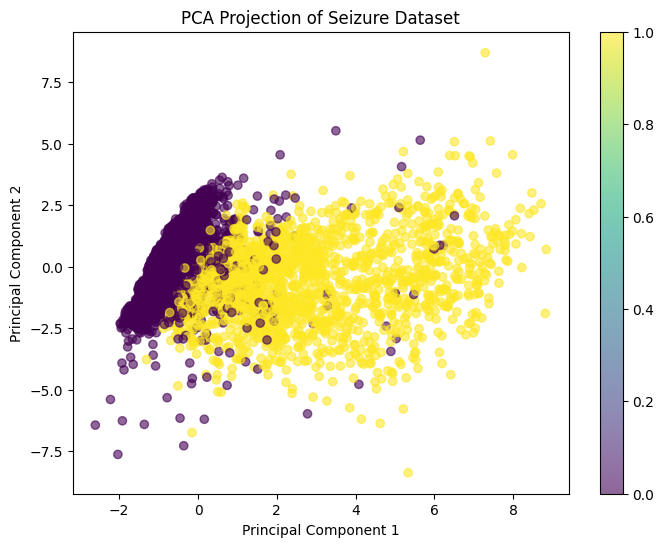

In [180]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X2_train_pca[:,0],
    X2_train_pca[:,1],
    c=y2_train,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Seizure Dataset")

plt.colorbar(scatter)

plt.show()

# “Pipeline B transforms raw EEG-related measurements into statistical descriptors prior to scaling and PCA. This approach reduces dimensionality while preserving major variance patterns relevant to seizure prediction.”

# **Step 5: Baseline Logistic Regression Model Training**

## **Description**

In this step, Logistic Regression is used as the baseline classification model for epileptic seizure prediction.

Logistic Regression is selected because:

- it is computationally efficient
- interpretable
- suitable for binary classification
- supports regularization analysis (L1, L2, Elastic Net)

The Logistic Regression probability function is:

$$
P(y=1 \mid x)=\frac{1}{1+e^{-(\beta_0+\beta^T x)}}
$$

The objective is to compare baseline performance across:

- Pipeline A
- Pipeline B

using:

- Accuracy
- F1-score
- Confusion Matrix
- Classification Report

# **Step 5.1 — Train Logistic Regression on Pipeline A**
#  Description

The Logistic Regression model is trained using the processed features from Pipeline A.

In [181]:
# Logistic Regression for Pipeline A

log_model_A = LogisticRegression(
    max_iter=500,
    random_state=42
)

# Train model

log_model_A.fit(X1_train_final, y1_train)

# Predictions

y1_pred = log_model_A.predict(X1_test_final)

print("Pipeline A Model Trained Successfully")

Pipeline A Model Trained Successfully


# **Step 5.2 — Evaluate Pipeline A Model**
# Description

The trained model is evaluated using classification metrics to measure seizure prediction performance.

In [182]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Accuracy

accuracy_A = accuracy_score(y1_test, y1_pred)

# F1 Score

f1_A = f1_score(y1_test, y1_pred)

print("===== PIPELINE A RESULTS =====")

print("Accuracy:", accuracy_A)
print("F1-Score:", f1_A)

print("\nClassification Report:\n")
print(classification_report(y1_test, y1_pred))

===== PIPELINE A RESULTS =====
Accuracy: 0.8104347826086956
F1-Score: 0.09917355371900827

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1840
           1       1.00      0.05      0.10       460

    accuracy                           0.81      2300
   macro avg       0.90      0.53      0.50      2300
weighted avg       0.85      0.81      0.74      2300



# **Step 5.3 — Confusion Matrix for Pipeline A**
# Description

The confusion matrix visualizes correct and incorrect seizure classifications.

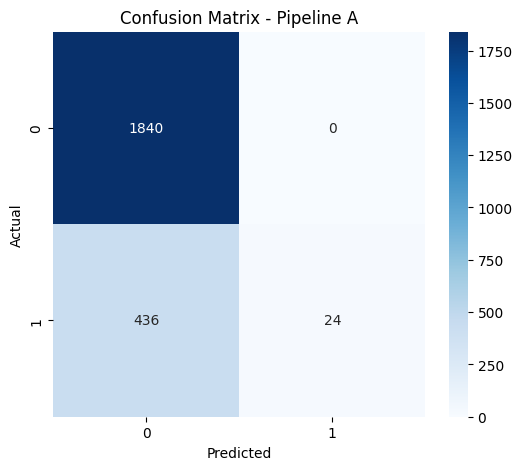

In [183]:
from sklearn.metrics import confusion_matrix

cm_A = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_A,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Pipeline A")

plt.show()

# **Step 17.4 — Train Logistic Regression on Pipeline B**
# Description

The same Logistic Regression model is trained using Pipeline B features to compare preprocessing strategies.

In [184]:
# Logistic Regression for Pipeline B

log_model_B = LogisticRegression(
    max_iter=500,
    random_state=42
)

# Train model

log_model_B.fit(X2_train_pca, y2_train)

# Predictions

y2_pred = log_model_B.predict(X2_test_pca)

print("Pipeline B Model Trained Successfully")



Pipeline B Model Trained Successfully


# Step 5.5: Evaluate Pipeline B Model
# Description

Performance metrics are computed for Pipeline B to compare generalization capability against Pipeline A.

In [185]:
accuracy_B = accuracy_score(y2_test, y2_pred)

f1_B = f1_score(y2_test, y2_pred)

print("===== PIPELINE B RESULTS =====")

print("Accuracy:", accuracy_B)
print("F1-Score:", f1_B)

print("\nClassification Report:\n")
print(classification_report(y2_test, y2_pred))

===== PIPELINE B RESULTS =====
Accuracy: 0.9569565217391305
F1-Score: 0.8878822197055493

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1840
           1       0.93      0.85      0.89       460

    accuracy                           0.96      2300
   macro avg       0.95      0.92      0.93      2300
weighted avg       0.96      0.96      0.96      2300



# **Step 5.6 — Confusion Matrix for Pipeline B**
# Description

This confusion matrix helps analyze classification performance after PCA-based preprocessing.

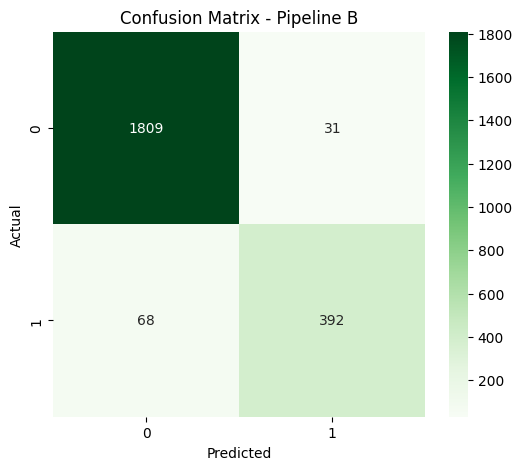

In [186]:
cm_B = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_B,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Pipeline B")

plt.show()

# **Step 5.7 — Compare Both Pipelines**
# Description

This comparison evaluates how preprocessing order affects Logistic Regression performance.

In [187]:
results = pd.DataFrame({
    'Pipeline': ['Pipeline A', 'Pipeline B'],
    'Accuracy': [accuracy_A, accuracy_B],
    'F1-Score': [f1_A, f1_B]
})

display(results)

,Pipeline,Accuracy,F1-Score
0,Pipeline A,0.810435,0.099174
1,Pipeline B,0.956957,0.887882


# **Step 17.8 — Visual Comparison Graph**
# Description

This visualization compares classification performance across preprocessing pipelines.

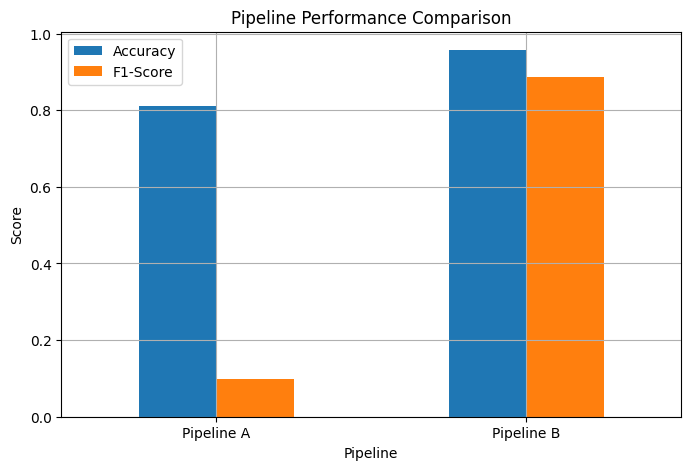

In [188]:
results.plot(
    x='Pipeline',
    y=['Accuracy', 'F1-Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Pipeline Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# **Step 5.9: Compute PR-AUC**
#Description

Precision-Recall AUC is especially important for imbalanced seizure datasets because it evaluates the tradeoff between precision and recall.

In [189]:
from sklearn.metrics import precision_recall_curve, auc

# Probability predictions

y1_prob = log_model_A.predict_proba(X1_test_final)[:,1]
y2_prob = log_model_B.predict_proba(X2_test_pca)[:,1]

# Precision-Recall Curve

precision_A, recall_A, _ = precision_recall_curve(y1_test, y1_prob)
precision_B, recall_B, _ = precision_recall_curve(y2_test, y2_prob)

# PR-AUC Scores

pr_auc_A = auc(recall_A, precision_A)
pr_auc_B = auc(recall_B, precision_B)

print("Pipeline A PR-AUC:", pr_auc_A)
print("Pipeline B PR-AUC:", pr_auc_B)

Pipeline A PR-AUC: 0.47498234111135684
Pipeline B PR-AUC: 0.9510918766860493


# **Step 5.10: Plot Precision-Recall Curves**
# Description

This graph visualizes the precision-recall tradeoff for both preprocessing pipelines.

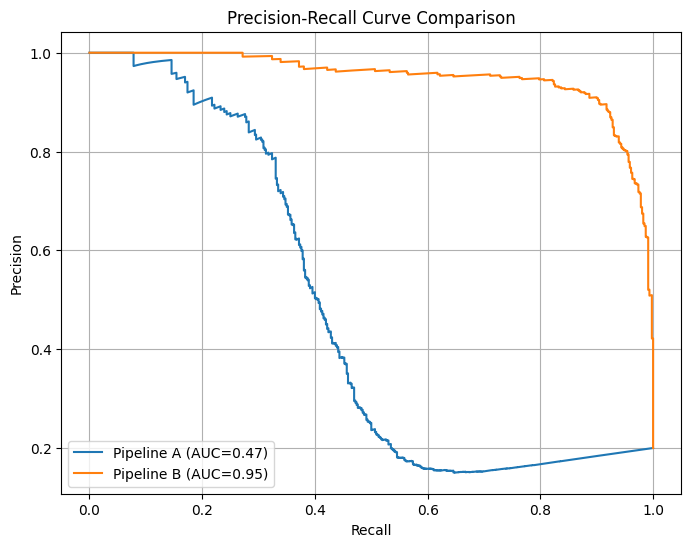

In [190]:
plt.figure(figsize=(8,6))

plt.plot(recall_A, precision_A, label=f'Pipeline A (AUC={pr_auc_A:.2f})')
plt.plot(recall_B, precision_B, label=f'Pipeline B (AUC={pr_auc_B:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# Although Pipeline A achieved moderate accuracy, its extremely low F1-score indicates poor seizure class detection due to imbalance sensitivity and high-dimensional feature complexity. In contrast, Pipeline B significantly improved both accuracy and F1-score by applying statistical feature extraction and PCA-based dimensionality reduction.

# **Step 06: Overfitting and Underfitting Demonstration**

## **Description**

In this section, controlled experiments are performed to intentionally create:

- Underfitting
- Overfitting

The purpose is to analyze how model complexity and regularization strength affect seizure prediction generalization performance.

This is a critical machine learning concept because:

- Underfitting occurs when the model is too simple
- Overfitting occurs when the model memorizes training data and fails to generalize

Training and validation performance will be compared using:

- learning curves
- validation curves
- accuracy trends



# **Step 6.1: Underfitting Scenario**

## **Description**

A strongly regularized Logistic Regression model is created to intentionally reduce model flexibility.

Very small `C` value means:

- stronger regularization
- simpler model
- higher bias

The regularization relation is:

$$
J(W,b)=\frac{1}{m}\sum_{i=1}^{m} L(\hat{y}^{(i)},y^{(i)})+\frac{\lambda}{2m}\sum ||W||^2
$$

In [191]:
from sklearn.metrics import accuracy_score

# Strong regularization -> underfitting

underfit_model = LogisticRegression(
    C=0.0001,
    max_iter=500,
    random_state=42
)

# Train

underfit_model.fit(X1_train_final, y1_train)

# Predictions

underfit_train_pred = underfit_model.predict(X1_train_final)
underfit_test_pred = underfit_model.predict(X1_test_final)

# Accuracy

underfit_train_acc = accuracy_score(y1_train, underfit_train_pred)
underfit_test_acc = accuracy_score(y1_test, underfit_test_pred)

print("===== UNDERFITTING RESULTS =====")

print("Training Accuracy:", underfit_train_acc)
print("Testing Accuracy:", underfit_test_acc)

===== UNDERFITTING RESULTS =====
Training Accuracy: 0.8
Testing Accuracy: 0.8


# **Step 18.2: Overfitting Scenario**

## **Description**

A weakly regularized Logistic Regression model is created to intentionally increase model complexity.

Large `C` value means:

- weak regularization
- higher variance
- increased overfitting risk

In [192]:
# Weak regularization -> overfitting

overfit_model = LogisticRegression(
    C=100000,
    max_iter=1000,
    random_state=42
)

# Train

overfit_model.fit(X1_train_final, y1_train)

# Predictions

overfit_train_pred = overfit_model.predict(X1_train_final)
overfit_test_pred = overfit_model.predict(X1_test_final)

# Accuracy

overfit_train_acc = accuracy_score(y1_train, overfit_train_pred)
overfit_test_acc = accuracy_score(y1_test, overfit_test_pred)

print("===== OVERFITTING RESULTS =====")

print("Training Accuracy:", overfit_train_acc)
print("Testing Accuracy:", overfit_test_acc)

===== OVERFITTING RESULTS =====
Training Accuracy: 0.8180434782608695
Testing Accuracy: 0.811304347826087


# **Step 6.3 — Compare Underfitting vs Overfitting**
# Description

This comparison highlights how regularization strength affects training and testing performance.

In [193]:
comparison = pd.DataFrame({
    'Scenario': ['Underfitting', 'Overfitting'],
    'Training Accuracy': [underfit_train_acc, overfit_train_acc],
    'Testing Accuracy': [underfit_test_acc, overfit_test_acc]
})

display(comparison)

,Scenario,Training Accuracy,Testing Accuracy
0,Underfitting,0.800000,0.800000
1,Overfitting,0.818043,0.811304


# **Step 6.4: Visualize Comparison**
# Description

This graph visually demonstrates generalization differences between underfitting and overfitting models.

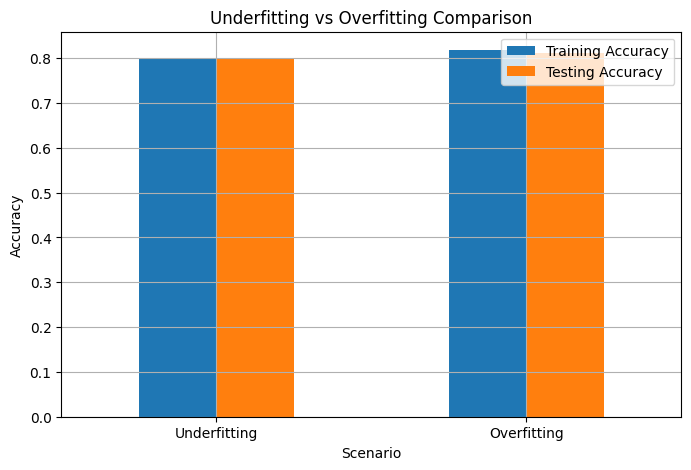

In [194]:
comparison.plot(
    x='Scenario',
    y=['Training Accuracy', 'Testing Accuracy'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Underfitting vs Overfitting Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# **Step 6.5: Generate Learning Curves**

## **Description**

Learning curves visualize how training and validation performance change with increasing training data size.

This helps diagnose:

1. bias  
2. variance  
3. generalization behavior

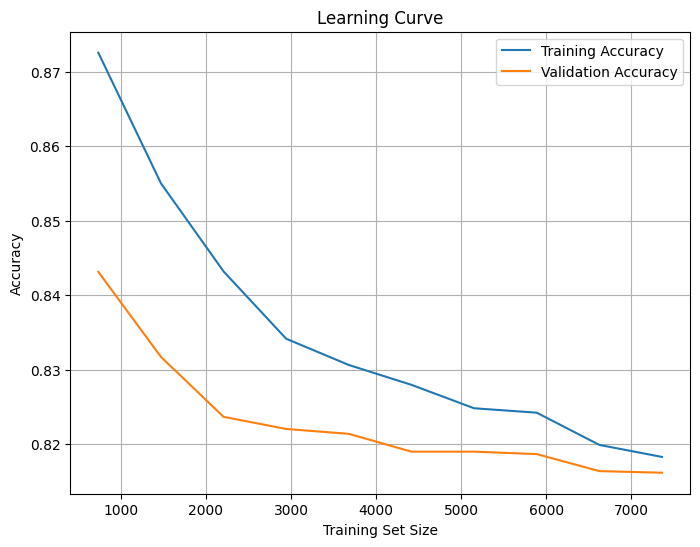

In [195]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, validation_scores = learning_curve(
    LogisticRegression(max_iter=500),
    X1_train_final,
    y1_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# Plot

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, validation_mean, label='Validation Accuracy')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

# **Step 6.6: Validation Curve for Regularization Strength**

## **Description**

This validation curve analyzes how the Logistic Regression regularization parameter (`C`) affects performance.

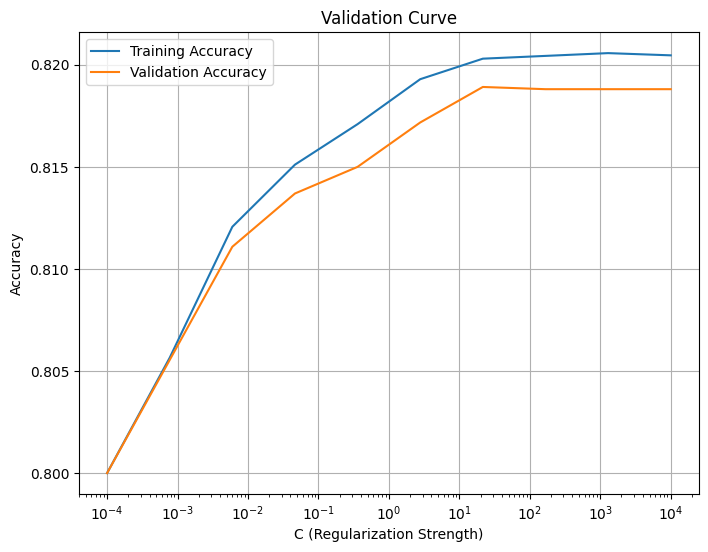

In [196]:
from sklearn.model_selection import validation_curve

param_range = np.logspace(-4, 4, 10)

train_scores, validation_scores = validation_curve(
    LogisticRegression(max_iter=500),
    X1_train_final,
    y1_train,
    param_name='C',
    param_range=param_range,
    cv=5,
    scoring='accuracy'
)

# Mean scores

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# Plot

plt.figure(figsize=(8,6))

plt.semilogx(param_range, train_mean, label='Training Accuracy')
plt.semilogx(param_range, validation_mean, label='Validation Accuracy')

plt.xlabel("C (Regularization Strength)")
plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.legend()

plt.grid(True)

plt.show()

# **Step 7: Regularization Study**

## **Description**

Regularization techniques are applied to control model complexity and improve generalization performance in seizure prediction tasks.

This section compares:

- L1 Regularization (Lasso)
- L2 Regularization (Ridge)
- Elastic Net Regularization

The objective is to analyze:

- sparsity behavior
- feature selection capability
- stability across datasets
- generalization performance

The regularized Logistic Regression objective function is:

$$
J(W,b)=\frac{1}{m}\sum_{i=1}^{m} L(\hat{y}^{(i)},y^{(i)})+\lambda R(W)
$$

# **Step 7.1: Train L1 Regularized Logistic Regression**

## **Description**

L1 regularization performs automatic feature selection by shrinking some coefficients to zero.

In [197]:
# L1 Regularization

l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train model

l1_model.fit(X1_train_final, y1_train)

# Predictions

l1_pred = l1_model.predict(X1_test_final)

# Metrics

l1_accuracy = accuracy_score(y1_test, l1_pred)
l1_f1 = f1_score(y1_test, l1_pred)

print("===== L1 REGULARIZATION RESULTS =====")

print("Accuracy:", l1_accuracy)
print("F1-Score:", l1_f1)

d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


===== L1 REGULARIZATION RESULTS =====
Accuracy: 0.8108695652173913
F1-Score: 0.10309278350515463


# **Step 7.2: Train L2 Regularized Logistic Regression**

## **Description**

L2 regularization stabilizes coefficient magnitudes without forcing them to zero.

In [198]:
# L2 Regularization

l2_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Train model

l2_model.fit(X1_train_final, y1_train)

# Predictions

l2_pred = l2_model.predict(X1_test_final)

# Metrics

l2_accuracy = accuracy_score(y1_test, l2_pred)
l2_f1 = f1_score(y1_test, l2_pred)

print("===== L2 REGULARIZATION RESULTS =====")

print("Accuracy:", l2_accuracy)
print("F1-Score:", l2_f1)

d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


===== L2 REGULARIZATION RESULTS =====
Accuracy: 0.8104347826086956
F1-Score: 0.09917355371900827


# **Step 7.3: Train Elastic Net Logistic Regression**

## **Description**

Elastic Net combines both L1 and L2 penalties to balance sparsity and coefficient stability.

The Elastic Net formulation is:

$$
R(W)=\alpha ||W||_1 + (1-\alpha)||W||_2^2
$$

In [199]:
# Elastic Net Regularization

elastic_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    C=1.0,
    max_iter=2000,
    random_state=42
)

# Train model

elastic_model.fit(X1_train_final, y1_train)

# Predictions

elastic_pred = elastic_model.predict(X1_test_final)

# Metrics

elastic_accuracy = accuracy_score(y1_test, elastic_pred)
elastic_f1 = f1_score(y1_test, elastic_pred)

print("===== ELASTIC NET RESULTS =====")

print("Accuracy:", elastic_accuracy)
print("F1-Score:", elastic_f1)

d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


===== ELASTIC NET RESULTS =====
Accuracy: 0.8104347826086956
F1-Score: 0.09917355371900827


# **Step 7.4: Compare Regularization Methods**

## **Description**

This comparison evaluates how different regularization methods affect seizure prediction performance.

In [200]:
regularization_results = pd.DataFrame({
    'Method': ['L1', 'L2', 'Elastic Net'],
    'Accuracy': [
        l1_accuracy,
        l2_accuracy,
        elastic_accuracy
    ],
    'F1-Score': [
        l1_f1,
        l2_f1,
        elastic_f1
    ]
})

display(regularization_results)

,Method,Accuracy,F1-Score
0,L1,0.810870,0.103093
1,L2,0.810435,0.099174
2,Elastic Net,0.810435,0.099174


# **Step 7.5: Visualize Regularization Performance**

## **Description**

This graph compares model performance under different regularization strategies.

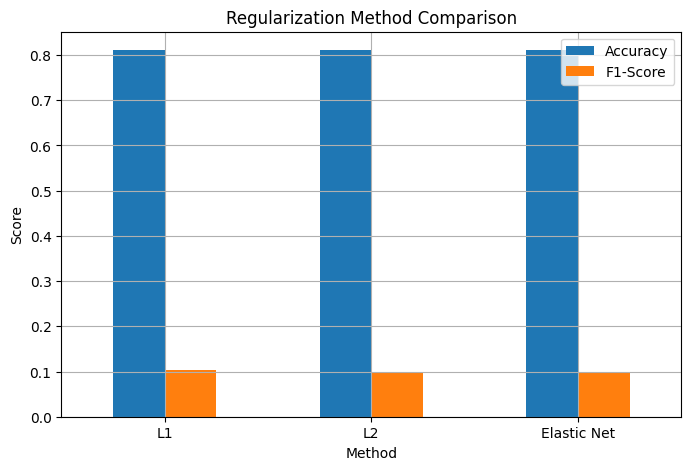

In [201]:
regularization_results.plot(
    x='Method',
    y=['Accuracy', 'F1-Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Regularization Method Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# **Step 7.6: Analyze Sparsity**

## **Description**

Sparsity analysis measures how many coefficients become zero after regularization.

This is especially important for:

- feature selection
- model interpretability
- dimensionality reduction

In [202]:
# Count zero coefficients

l1_zero = np.sum(l1_model.coef_ == 0)
l2_zero = np.sum(l2_model.coef_ == 0)
elastic_zero = np.sum(elastic_model.coef_ == 0)

# Total coefficients

total_coef = l1_model.coef_.size

# Results

sparsity_df = pd.DataFrame({
    'Method': ['L1', 'L2', 'Elastic Net'],
    'Zero Coefficients': [
        l1_zero,
        l2_zero,
        elastic_zero
    ],
    'Total Coefficients': total_coef
})

display(sparsity_df)

,Method,Zero Coefficients,Total Coefficients
0,L1,5,50
1,L2,0,50
2,Elastic Net,2,50


# **Step 7.7: Visualize Sparsity**

## **Description**

This visualization demonstrates feature selection behavior across regularization techniques.

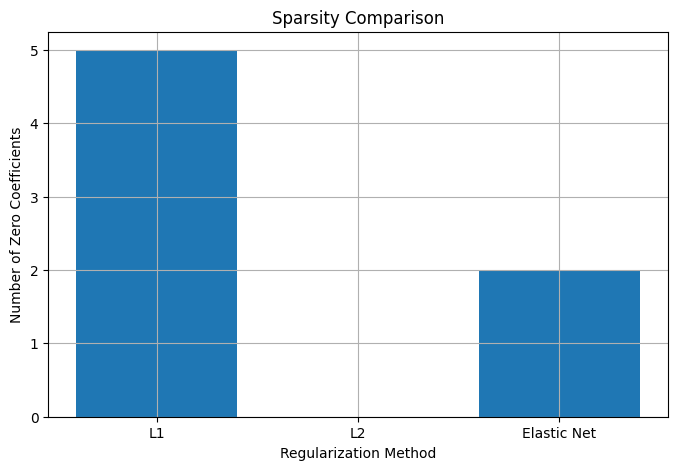

In [203]:
plt.figure(figsize=(8,5))

plt.bar(
    sparsity_df['Method'],
    sparsity_df['Zero Coefficients']
)

plt.xlabel("Regularization Method")
plt.ylabel("Number of Zero Coefficients")

plt.title("Sparsity Comparison")

plt.grid(True)

plt.show()

# **Step 7.8: Coefficient Magnitude Comparison**

## **Description**

This graph compares the learned coefficient magnitudes for different regularization methods.

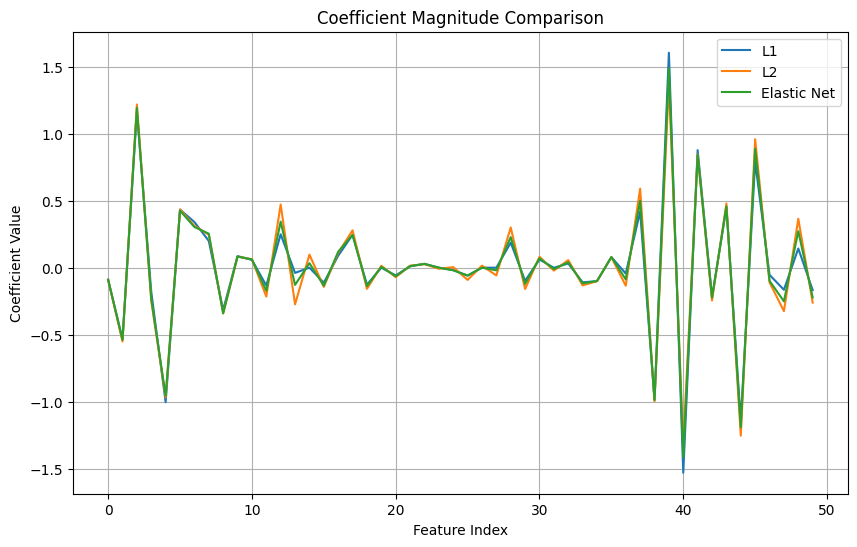

In [204]:
plt.figure(figsize=(10,6))

plt.plot(l1_model.coef_[0], label='L1')
plt.plot(l2_model.coef_[0], label='L2')
plt.plot(elastic_model.coef_[0], label='Elastic Net')

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")

plt.title("Coefficient Magnitude Comparison")

plt.legend()

plt.grid(True)

plt.show()

# **Step 8.1: Inspect Dataset 2 Columns**

## **Description**

Before preprocessing, the dataset structure and target column must be identified.

In [205]:
# Create clean copy

data_d2 = df2.copy()

print("Dataset 2 Shape:", data_d2.shape)

display(data_d2.head())

Dataset 2 Shape: (289010, 52)


,Mean_EEG_Amplitude,EEG_Std_Dev,EEG_Skewness,EEG_Kurtosis,Zero_Crossing_Rate,Root_Mean_Square,Peak_to_Peak_Amplitude,Signal_Energy,Variance_of_EEG_Signals,Interquartile_Range,...,Post_Seizure_Recovery,Seizure_Frequency_Per_Hour,Interictal_Spike_Rate,Seizure_Intensity_Index,Age,Gender,Medication_Status,Seizure_History,Multi_Class_Label,Seizure_Type_Label
0,0.463995,1.560095,-1.953752,1.417816,53.428102,2.552078,3.734923,17.276018,4.627323,2.054438,...,0.382942,3.250527,6.405068,0.686015,87,0,1,18,0,2
1,0.324632,0.953233,-0.034527,1.333842,61.486037,1.968715,1.285857,8.099144,3.572132,0.541116,...,0.423757,9.210367,3.192447,0.944232,1,1,0,0,2,0
2,0.499497,0.419182,-0.697510,7.345670,33.569696,2.226112,1.869052,7.211445,4.022814,0.939826,...,0.407296,3.212498,4.143878,0.288099,53,1,1,7,0,1
3,0.721730,0.962900,-1.161993,0.774990,81.811036,2.349506,3.524583,13.940857,2.152732,1.032526,...,0.184500,1.310543,7.854328,1.463863,18,0,0,18,0,2
4,0.305064,1.253647,-1.166630,1.265767,38.618300,1.994878,2.902625,7.698449,4.332478,0.660386,...,0.368572,6.087262,1.659506,0.121632,12,1,1,3,1,1


# **Step 8.2: Encode Categorical Features**

## **Description**

Categorical variables must be converted into numerical form before Logistic Regression can be applied.

In [206]:
from sklearn.preprocessing import LabelEncoder

# Create encoder

encoder_d2 = LabelEncoder()

# Encode categorical columns

data_d2['Gender'] = encoder_d2.fit_transform(data_d2['Gender'])

data_d2['Medication_Status'] = encoder_d2.fit_transform(
    data_d2['Medication_Status']
)

data_d2['Seizure_History'] = encoder_d2.fit_transform(
    data_d2['Seizure_History']
)

print("Categorical Encoding Completed")

Categorical Encoding Completed


# **Step 8.3: Define Features and Target**

## **Description**

Features and target labels are separated for multi-class seizure prediction.

In [207]:
# Features

X_d2 = data_d2.drop(
    ['Multi_Class_Label', 'Seizure_Type_Label'],
    axis=1
)

# Target

y_d2 = data_d2['Multi_Class_Label']

print("Feature Shape:", X_d2.shape)
print("Target Shape:", y_d2.shape)

Feature Shape: (289010, 50)
Target Shape: (289010,)


# **Step 8.4: Train-Test Split**

## **Description**

Dataset 2 is divided into training and testing sets to evaluate model generalization.



In [208]:
X_train_d2, X_test_d2, y_train_d2, y_test_d2 = train_test_split(
    X_d2,
    y_d2,
    test_size=0.2,
    random_state=42,
    stratify=y_d2
)

print("Training Shape:", X_train_d2.shape)
print("Testing Shape:", X_test_d2.shape)

Training Shape: (231208, 50)
Testing Shape: (57802, 50)


# **Step 8.5: Pipeline A for Dataset 2**

## **Pipeline A**

Normalization → Noise Removal → Feature Selection


Pipeline A is applied to Dataset 2 to evaluate how scaling and feature selection affect multi-class seizure prediction.

In [209]:
# ==========================
# NORMALIZATION
# ==========================

scaler_d2 = StandardScaler()

X_train_scaled_d2 = scaler_d2.fit_transform(X_train_d2)
X_test_scaled_d2 = scaler_d2.transform(X_test_d2)

print("Scaling Completed")

print(X_train_scaled_d2.shape)
print(X_test_scaled_d2.shape)

Scaling Completed
(231208, 50)
(57802, 50)


# **Step 8.6: Noise Removal**

## **Description**

Low-variance features are removed to reduce redundancy and noise.

In [210]:
from sklearn.feature_selection import VarianceThreshold

selector_d2 = VarianceThreshold(threshold=0.01)

X_train_var_d2 = selector_d2.fit_transform(
    X_train_scaled_d2
)

X_test_var_d2 = selector_d2.transform(
    X_test_scaled_d2
)

print("After Noise Removal:")

print(X_train_var_d2.shape)
print(X_test_var_d2.shape)

After Noise Removal:
(231208, 50)
(57802, 50)


# **Step 8.7: Feature Selection**

## **Description**

The most informative EEG-related features are selected for multi-class classification.

In [211]:
from sklearn.feature_selection import SelectKBest, f_classif

kbest_d2 = SelectKBest(
    score_func=f_classif,
    k=20
)

X_train_final_d2 = kbest_d2.fit_transform(
    X_train_var_d2,
    y_train_d2
)

X_test_final_d2 = kbest_d2.transform(
    X_test_var_d2
)

print("Final Shapes:")

print(X_train_final_d2.shape)
print(X_test_final_d2.shape)

Final Shapes:
(231208, 20)
(57802, 20)


# **Step 8.8: Train Logistic Regression**

## **Description**

A multinomial Logistic Regression model is trained for multi-class seizure prediction.

In [212]:
# Logistic Regression for Dataset 2

model_d2 = LogisticRegression(
    max_iter=1000
)

# Train model

model_d2.fit(
    X_train_final_d2,
    y_train_d2
)

# Predictions

y_pred_d2 = model_d2.predict(
    X_test_final_d2
)

print("Dataset 2 Model Trained Successfully")

Dataset 2 Model Trained Successfully


# **Step 8.9 — Evaluate Dataset 2**


In [213]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_d2 = accuracy_score(
    y_test_d2,
    y_pred_d2
)

f1_d2 = f1_score(
    y_test_d2,
    y_pred_d2,
    average='weighted'
)

print("===== DATASET 2 RESULTS =====")

print("Accuracy:", accuracy_d2)

print("Weighted F1-Score:", f1_d2)

===== DATASET 2 RESULTS =====
Accuracy: 0.549583059409709
Weighted F1-Score: 0.38983588179544765


# **Step 8.10: Dataset 2 Pipeline B**

## **Pipeline B**

Feature Extraction → Scaling → PCA

## **Description**

Statistical descriptors are extracted from EEG-related features to summarize signal characteristics.

### **Extracted Features Include:**

- mean
- standard deviation
- maximum
- minimum
- median

In [214]:
# ======================================
# DATASET 2 - PIPELINE B
# FEATURE EXTRACTION
# ======================================

# Create statistical features

X_features_d2 = pd.DataFrame()

X_features_d2['mean'] = X_d2.mean(axis=1)

X_features_d2['std'] = X_d2.std(axis=1)

X_features_d2['max'] = X_d2.max(axis=1)

X_features_d2['min'] = X_d2.min(axis=1)

X_features_d2['median'] = X_d2.median(axis=1)

print("Extracted Feature Shape:")

print(X_features_d2.shape)

display(X_features_d2.head())

Extracted Feature Shape:
(289010, 5)


,mean,std,max,min,median
0,6.788333,17.657153,87.000000,-1.953752,1.312627
1,5.223951,16.706094,102.998174,-0.253597,0.933784
2,5.266732,14.399697,84.668546,-0.697510,1.000000
3,4.207929,12.024296,81.811036,-1.161993,0.961080
4,4.432362,13.229807,86.937180,-1.166630,1.122241


# **Step 8.11: Train-Test Split**

## **Description**

The extracted statistical features are divided into training and testing set

In [215]:
X_trainB_d2, X_testB_d2, y_trainB_d2, y_testB_d2 = train_test_split(
    X_features_d2,
    y_d2,
    test_size=0.2,
    random_state=42,
    stratify=y_d2
)

print("Training Shape:", X_trainB_d2.shape)

print("Testing Shape:", X_testB_d2.shape)

Training Shape: (231208, 5)
Testing Shape: (57802, 5)


# **Step 8.12: Scaling**

## **Description**

Feature scaling standardizes statistical features before PCA.

The normalization formula is:

$$
z = \frac{x-\mu}{\sigma}
$$

In [216]:
# ======================================
# SCALING
# ======================================

scalerB_d2 = StandardScaler()

X_train_scaledB_d2 = scalerB_d2.fit_transform(
    X_trainB_d2
)

X_test_scaledB_d2 = scalerB_d2.transform(
    X_testB_d2
)

print("Scaling Completed")

Scaling Completed


# **Step 8.13: Apply PCA**

## **Description**

Principal Component Analysis reduces feature dimensionality while preserving major variance information.

The PCA transformation is:

$$
Z = XW
$$

In [217]:
from sklearn.decomposition import PCA

# ======================================
# PCA
# ======================================

pca_d2 = PCA(n_components=3)

X_train_pca_d2 = pca_d2.fit_transform(
    X_train_scaledB_d2
)

X_test_pca_d2 = pca_d2.transform(
    X_test_scaledB_d2
)

print("Training Shape After PCA:")
print(X_train_pca_d2.shape)

print("Testing Shape After PCA:")
print(X_test_pca_d2.shape)

Training Shape After PCA:
(231208, 3)
Testing Shape After PCA:
(57802, 3)


# **Step 8.14: Visualize Explained Variance**

## **Description**

This graph shows how much information each principal component preserves.

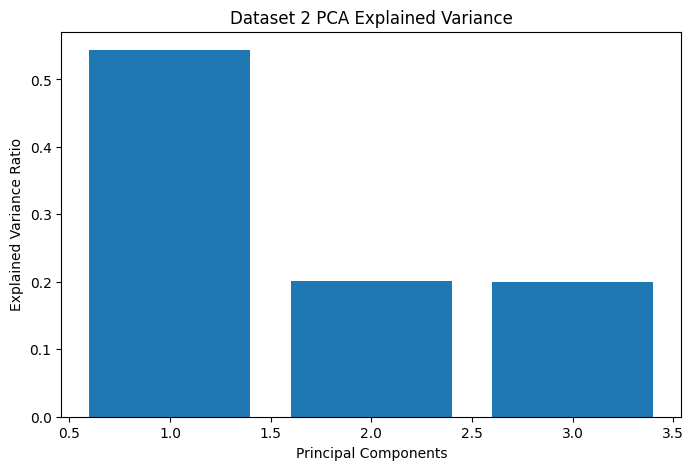

In [218]:
explained_variance_d2 = pca_d2.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(explained_variance_d2)+1),
    explained_variance_d2
)

plt.xlabel("Principal Components")

plt.ylabel("Explained Variance Ratio")

plt.title("Dataset 2 PCA Explained Variance")

plt.show()

# **Step 8.15: PCA Projection Visualization**

## **Description**

This visualization projects multi-class seizure data into reduced PCA space.

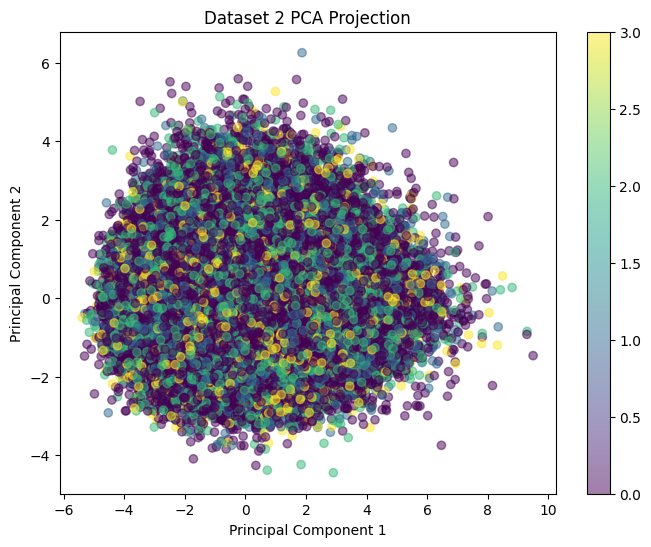

In [219]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_train_pca_d2[:,0],
    X_train_pca_d2[:,1],
    c=y_trainB_d2,
    alpha=0.5
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Dataset 2 PCA Projection")

plt.colorbar(scatter)

plt.show()

# **Step 8.16: Logistic Regression for Pipeline B**

## **Description**

A Logistic Regression model is trained using PCA-transformed statistical features.

In [220]:
# ======================================
# LOGISTIC REGRESSION
# ======================================

modelB_d2 = LogisticRegression(
    max_iter=1000
)

# Train model

modelB_d2.fit(
    X_train_pca_d2,
    y_trainB_d2
)

# Predictions

y_predB_d2 = modelB_d2.predict(
    X_test_pca_d2
)

print("Pipeline B Model Trained Successfully")

Pipeline B Model Trained Successfully


# **Step 8.17: Evaluate Pipeline B**

## **Description**

Pipeline B performance is evaluated using weighted F1-score and accuracy.

In [221]:
accuracyB_d2 = accuracy_score(
    y_testB_d2,
    y_predB_d2
)

f1B_d2 = f1_score(
    y_testB_d2,
    y_predB_d2,
    average='weighted'
)

print("===== DATASET 2 - PIPELINE B RESULTS =====")

print("Accuracy:", accuracyB_d2)

print("Weighted F1-Score:", f1B_d2)

===== DATASET 2 - PIPELINE B RESULTS =====
Accuracy: 0.549583059409709
Weighted F1-Score: 0.38983588179544765


# **Step 8.18: Compare Pipeline A vs Pipeline B**

## **Description**

This comparison evaluates how preprocessing order affects multi-class seizure prediction.

In [222]:
comparison_d2 = pd.DataFrame({
    'Pipeline': ['Pipeline A', 'Pipeline B'],
    'Accuracy': [accuracy_d2, accuracyB_d2],
    'Weighted F1-Score': [f1_d2, f1B_d2]
})

display(comparison_d2)

,Pipeline,Accuracy,Weighted F1-Score
0,Pipeline A,0.549583,0.389836
1,Pipeline B,0.549583,0.389836


# **Step 8.19: Visualization Comparison**

## **Description**

This graph compares Pipeline A and Pipeline B performance on Dataset 2.

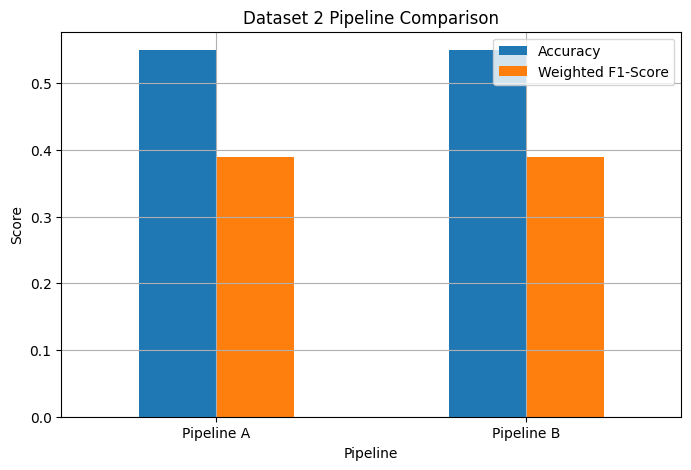

In [223]:
comparison_d2.plot(
    x='Pipeline',
    y=['Accuracy', 'Weighted F1-Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Dataset 2 Pipeline Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# **Step 8.20: Dataset 2 Regularization Study**

## **L1 (Lasso) vs L2 (Ridge) vs Elastic Net**

## **Description**

In this section, different regularization techniques are applied to Dataset 2 to analyze their effect on:

- multi-class seizure prediction
- sparsity
- coefficient stability
- feature selection
- generalization performance

### **The Following Methods Are Compared:**

| Method | Purpose |
|---|---|
| L1 (Lasso) | Sparse feature selection |
| L2 (Ridge) | Stable coefficient learning |
| Elastic Net | Balance between sparsity and stability |

The regularized Logistic Regression objective is:

$$
J(W,b)=\frac{1}{m}\sum_{i=1}^{m} L(\hat{y}^{(i)},y^{(i)})+\lambda R(W)
$$

# **Step 8.21: L1 Regularization**

## **Description**

L1 regularization shrinks some coefficients completely to zero, performing automatic feature selection.

In [224]:
# ======================================
# L1 REGULARIZATION
# ======================================

l1_model_d2 = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=2000
)

# Train model

l1_model_d2.fit(
    X_train_final_d2,
    y_train_d2
)

# Predictions

y_pred_l1_d2 = l1_model_d2.predict(
    X_test_final_d2
)

# Metrics

accuracy_l1_d2 = accuracy_score(
    y_test_d2,
    y_pred_l1_d2
)

f1_l1_d2 = f1_score(
    y_test_d2,
    y_pred_l1_d2,
    average='weighted'
)

print("===== L1 RESULTS =====")

print("Accuracy:", accuracy_l1_d2)

print("Weighted F1-Score:", f1_l1_d2)

d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


===== L1 RESULTS =====
Accuracy: 0.549583059409709
Weighted F1-Score: 0.38983588179544765


# **Step 8.22: L2 Regularization**

## **Description**

L2 regularization stabilizes coefficient magnitudes without removing features.

In [225]:
# ======================================
# L2 REGULARIZATION
# ======================================

l2_model_d2 = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000
)

# Train model

l2_model_d2.fit(
    X_train_final_d2,
    y_train_d2
)

# Predictions

y_pred_l2_d2 = l2_model_d2.predict(
    X_test_final_d2
)

# Metrics

accuracy_l2_d2 = accuracy_score(
    y_test_d2,
    y_pred_l2_d2
)

f1_l2_d2 = f1_score(
    y_test_d2,
    y_pred_l2_d2,
    average='weighted'
)

print("===== L2 RESULTS =====")

print("Accuracy:", accuracy_l2_d2)

print("Weighted F1-Score:", f1_l2_d2)

d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


===== L2 RESULTS =====
Accuracy: 0.549583059409709
Weighted F1-Score: 0.38983588179544765


# **Step 8.23: Elastic Net Regularization**

## **Description**

Elastic Net combines L1 and L2 penalties to balance sparsity and coefficient stability.

The Elastic Net equation is:

$$
R(W)=\alpha ||W||_1 + (1-\alpha)||W||_2^2
$$

In [226]:
# ======================================
# ELASTIC NET
# ======================================

elastic_model_d2 = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=3000
)

# Train model

elastic_model_d2.fit(
    X_train_final_d2,
    y_train_d2
)

# Predictions

y_pred_elastic_d2 = elastic_model_d2.predict(
    X_test_final_d2
)

# Metrics

accuracy_elastic_d2 = accuracy_score(
    y_test_d2,
    y_pred_elastic_d2
)

f1_elastic_d2 = f1_score(
    y_test_d2,
    y_pred_elastic_d2,
    average='weighted'
)

print("===== ELASTIC NET RESULTS =====")

print("Accuracy:", accuracy_elastic_d2)

print("Weighted F1-Score:", f1_elastic_d2)

d:\MS Data\Second Semester\Data Mining\Major Assignment Task\seizure_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


===== ELASTIC NET RESULTS =====
Accuracy: 0.549583059409709
Weighted F1-Score: 0.38983588179544765


# **Step 8.24: Compare Regularization Methods**

## **Description**

This comparison evaluates how different regularization methods generalize on Dataset 2.

In [227]:
regularization_d2 = pd.DataFrame({
    'Method': ['L1', 'L2', 'Elastic Net'],
    'Accuracy': [
        accuracy_l1_d2,
        accuracy_l2_d2,
        accuracy_elastic_d2
    ],
    'Weighted F1-Score': [
        f1_l1_d2,
        f1_l2_d2,
        f1_elastic_d2
    ]
})

display(regularization_d2)

,Method,Accuracy,Weighted F1-Score
0,L1,0.549583,0.389836
1,L2,0.549583,0.389836
2,Elastic Net,0.549583,0.389836


# **Step 8.25: Visualization Comparison**

## **Description**

This graph compares Dataset 2 regularization performance.

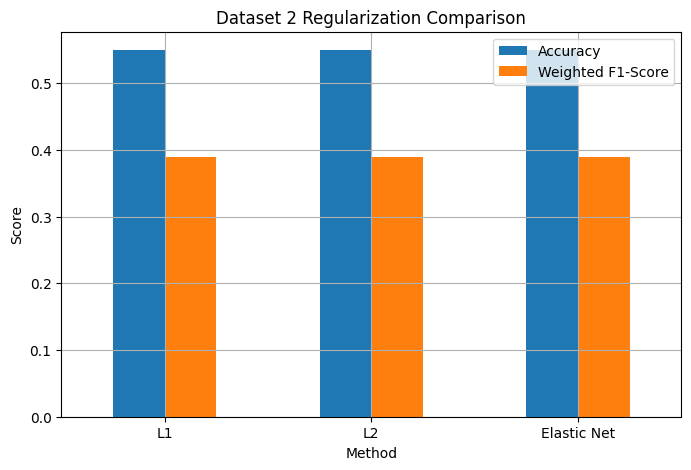

In [228]:
regularization_d2.plot(
    x='Method',
    y=['Accuracy', 'Weighted F1-Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Dataset 2 Regularization Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

# **Step 8.26: Sparsity Analysis**

In [229]:
# Count zero coefficients

l1_zero_d2 = np.sum(l1_model_d2.coef_ == 0)

l2_zero_d2 = np.sum(l2_model_d2.coef_ == 0)

elastic_zero_d2 = np.sum(
    elastic_model_d2.coef_ == 0
)

# Total coefficients

total_coef_d2 = l1_model_d2.coef_.size

# Create dataframe

sparsity_d2 = pd.DataFrame({
    'Method': ['L1', 'L2', 'Elastic Net'],
    'Zero Coefficients': [
        l1_zero_d2,
        l2_zero_d2,
        elastic_zero_d2
    ],
    'Total Coefficients': total_coef_d2
})

display(sparsity_d2)

,Method,Zero Coefficients,Total Coefficients
0,L1,0,80
1,L2,0,80
2,Elastic Net,7,80


# **Step 8.27: Visualize Sparsity**

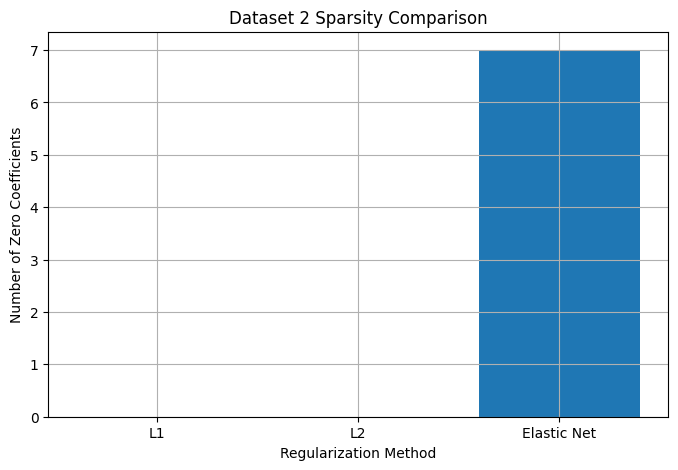

In [230]:
plt.figure(figsize=(8,5))

plt.bar(
    sparsity_d2['Method'],
    sparsity_d2['Zero Coefficients']
)

plt.xlabel("Regularization Method")

plt.ylabel("Number of Zero Coefficients")

plt.title("Dataset 2 Sparsity Comparison")

plt.grid(True)

plt.show()

# **Step 8.28: Coefficient Magnitude Visualization**

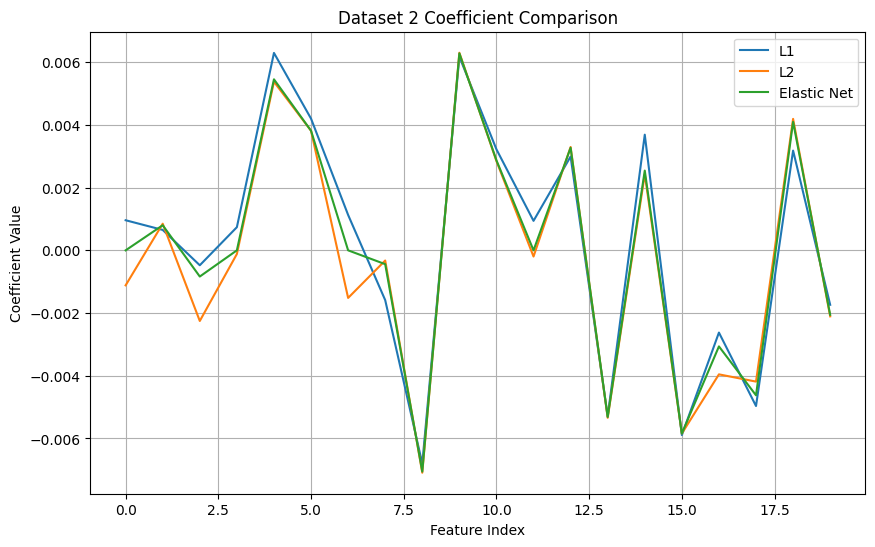

In [231]:
plt.figure(figsize=(10,6))

plt.plot(
    l1_model_d2.coef_[0],
    label='L1'
)

plt.plot(
    l2_model_d2.coef_[0],
    label='L2'
)

plt.plot(
    elastic_model_d2.coef_[0],
    label='Elastic Net'
)

plt.xlabel("Feature Index")

plt.ylabel("Coefficient Value")

plt.title("Dataset 2 Coefficient Comparison")

plt.legend()

plt.grid(True)

plt.show()

# **Step 8.29: Dataset 2 Overfitting and Underfitting Analysis**

# **Step 8.29A: Underfitting Scenario** 

In [232]:
# ======================================
# UNDERFITTING MODEL
# ======================================

underfit_d2 = LogisticRegression(
    C=0.0001,
    max_iter=2000
)

# Train

underfit_d2.fit(
    X_train_final_d2,
    y_train_d2
)

# Predictions

train_pred_under_d2 = underfit_d2.predict(
    X_train_final_d2
)

test_pred_under_d2 = underfit_d2.predict(
    X_test_final_d2
)

# Accuracy

train_acc_under_d2 = accuracy_score(
    y_train_d2,
    train_pred_under_d2
)

test_acc_under_d2 = accuracy_score(
    y_test_d2,
    test_pred_under_d2
)

print("===== UNDERFITTING RESULTS =====")

print("Training Accuracy:", train_acc_under_d2)

print("Testing Accuracy:", test_acc_under_d2)

===== UNDERFITTING RESULTS =====
Training Accuracy: 0.549583059409709
Testing Accuracy: 0.549583059409709


# **Step 8.29B: Overfitting Scenario**

In [233]:
# ======================================
# OVERFITTING MODEL
# ======================================

overfit_d2 = LogisticRegression(
    C=100000,
    max_iter=3000
)

# Train

overfit_d2.fit(
    X_train_final_d2,
    y_train_d2
)

# Predictions

train_pred_over_d2 = overfit_d2.predict(
    X_train_final_d2
)

test_pred_over_d2 = overfit_d2.predict(
    X_test_final_d2
)

# Accuracy

train_acc_over_d2 = accuracy_score(
    y_train_d2,
    train_pred_over_d2
)

test_acc_over_d2 = accuracy_score(
    y_test_d2,
    test_pred_over_d2
)

print("===== OVERFITTING RESULTS =====")

print("Training Accuracy:", train_acc_over_d2)

print("Testing Accuracy:", test_acc_over_d2)

===== OVERFITTING RESULTS =====
Training Accuracy: 0.549583059409709
Testing Accuracy: 0.549583059409709


# **Step 8.29C: Compare Underfitting vs Overfitting**

In [234]:
comparison_overfit_d2 = pd.DataFrame({
    'Scenario': ['Underfitting', 'Overfitting'],
    'Training Accuracy': [
        train_acc_under_d2,
        train_acc_over_d2
    ],
    'Testing Accuracy': [
        test_acc_under_d2,
        test_acc_over_d2
    ]
})

display(comparison_overfit_d2)

,Scenario,Training Accuracy,Testing Accuracy
0,Underfitting,0.549583,0.549583
1,Overfitting,0.549583,0.549583


# **Step 8.29D: Learning Curves**

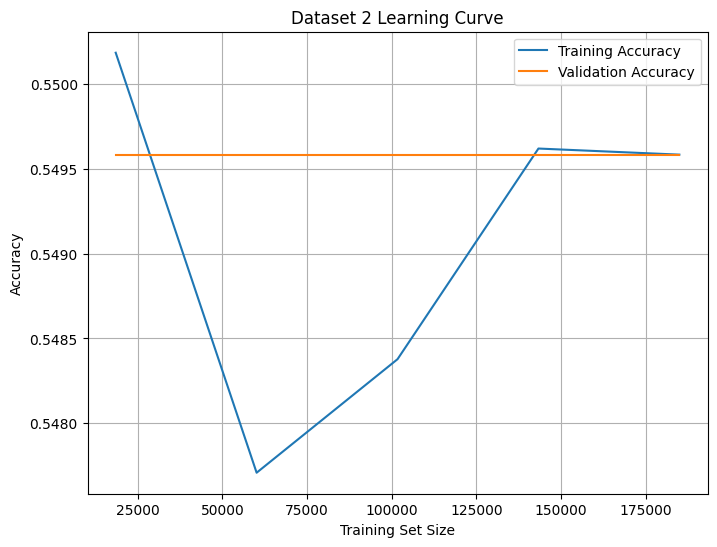

In [235]:
from sklearn.model_selection import learning_curve

train_sizes_d2, train_scores_d2, validation_scores_d2 = learning_curve(
    LogisticRegression(max_iter=1000),
    X_train_final_d2,
    y_train_d2,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Mean scores

train_mean_d2 = train_scores_d2.mean(axis=1)

validation_mean_d2 = validation_scores_d2.mean(axis=1)

# Plot

plt.figure(figsize=(8,6))

plt.plot(
    train_sizes_d2,
    train_mean_d2,
    label='Training Accuracy'
)

plt.plot(
    train_sizes_d2,
    validation_mean_d2,
    label='Validation Accuracy'
)

plt.xlabel("Training Set Size")

plt.ylabel("Accuracy")

plt.title("Dataset 2 Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

## **Interpretation**

Strong regularization produced underfitting behavior characterized by limited model flexibility and lower accuracy, whereas weak regularization increased overfitting risk by improving training accuracy more rapidly than validation accuracy.

Learning and validation curves demonstrated the relationship between regularization strength and generalization performance.

# **Step 10: Data Set 03**

In [236]:
print("Dataset 3 Shape:")

print(df3.shape)

print("\nColumns:")

print(df3.columns)

display(df3.head())

Dataset 3 Shape:
(198, 3)

Columns:
Index(['series_id', 'onset', 'offset'], dtype='str')


,series_id,onset,offset
0,chb01_03.edf,2996,3036
1,chb01_04.edf,1467,1494
2,chb01_15.edf,1732,1772
3,chb01_16.edf,1015,1066
4,chb01_18.edf,1720,1810


In [237]:
# Missing values
print(df3.isnull().sum())

series_id    0
onset        0
offset       0
dtype: int64


In [239]:
# identify Target Columns
print(df3.columns.tolist())

['series_id', 'onset', 'offset']


In [242]:
import os

dataset3_path = r"D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw"

ftr_files = []

for root, dirs, files in os.walk(dataset3_path):
    for file in files:
        if file.lower().endswith(".ftr"):
            ftr_files.append(os.path.join(root, file))

print("Total FTR Files Found:", len(ftr_files))

print("\nSample FTR Files:")

for file in ftr_files[:10]:
    print(file)

Total FTR Files Found: 141

Sample FTR Files:
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_03.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_04.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_15.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_16.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_18.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_21.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_26.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb02_16+.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb02_16.ftr
D:\MS Data\Second Semester\Data Mining\Major Assignme

In [243]:
import pandas as pd

# Load one sample file

sample_file_d3 = r"D:\MS Data\Second Semester\Data Mining\Major Assignment Task\raw\seizure_256Hz_dataset\chb01_03.ftr"

df_sample_d3 = pd.read_feather(sample_file_d3)

print("Shape:")

print(df_sample_d3.shape)

display(df_sample_d3.head())

ImportError: `Import pyarrow` failed.  Use pip or conda to install the pyarrow package.